# Loan Approval Outcome Prediction

> **Exploratory notebook:** This notebook uses a different feature set and selects XGBoost. The packaged training pipeline in src/loan_approval_prediction/ is authoritative for the FastAPI model; its results are in reports/evaluation.json and MODEL_CARD.md. Notebook metrics must not be presented as deployed-model metrics.

This notebook builds and compares leakage-safe classification pipelines for the historical `Loan_Status` outcome. It preserves the original project concepts—EDA, imputation, encoding, scaling, SMOTE, stratified cross-validation, hyperparameter tuning, probability calibration, threshold optimization, model comparison, and explainability—while keeping the final test set untouched until the end.

> **Scope:** This analyzes historical approval outcomes, not repayment default. Do not use its predictions for real lending decisions.

## 1. Environment setup

Install the project dependencies from the repository root with `uv sync --locked --link-mode copy`. Launch JupyterLab with `uv run --link-mode copy jupyter lab` and use the project's `.venv` Python kernel.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_FOLDS = 5
APPROVAL_LABEL = 1
REJECTION_LABEL = 0

## 2. Load and validate the dataset

The cell first checks common local and Colab paths. If the CSV is absent, it downloads the public Kaggle dataset with `kagglehub`.

In [3]:
import kagglehub

DATA_FILENAME = "train_u6lujuX_CVtuZ9i.csv"
candidate_paths = [
    Path(DATA_FILENAME),
    Path("data/raw") / DATA_FILENAME,
    Path("/content") / DATA_FILENAME,
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    dataset_dir = Path(
        kagglehub.dataset_download(
            "altruistdelhite04/loan-prediction-problem-dataset"
        )
    )
    matches = list(dataset_dir.rglob(DATA_FILENAME))
    if not matches:
        raise FileNotFoundError(f"{DATA_FILENAME} was not found in {dataset_dir}")
    data_path = matches[0]

df_raw = pd.read_csv(data_path)
print(f"Loaded: {data_path.name}")
print(f"Shape: {df_raw.shape}")
df_raw.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
EXPECTED_COLUMNS = {
    "Loan_ID", "Gender", "Married", "Dependents", "Education",
    "Self_Employed", "ApplicantIncome", "CoapplicantIncome",
    "LoanAmount", "Loan_Amount_Term", "Credit_History",
    "Property_Area", "Loan_Status",
}

missing_columns = EXPECTED_COLUMNS - set(df_raw.columns)
unexpected_columns = set(df_raw.columns) - EXPECTED_COLUMNS
assert not missing_columns, f"Missing required columns: {sorted(missing_columns)}"
assert not unexpected_columns, f"Unexpected columns: {sorted(unexpected_columns)}"
assert df_raw["Loan_ID"].notna().all(), "Loan_ID contains missing values."
assert df_raw["Loan_ID"].is_unique, "Loan_ID must uniquely identify applications."
assert df_raw["Loan_Status"].notna().all(), "Loan_Status contains missing values."
assert set(df_raw["Loan_Status"].unique()) == {"Y", "N"}

df = df_raw.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## 3. Define the target and create an untouched test set

`Loan_ID` is excluded because it is an identifier, not a predictive feature. The raw data is split before any learned imputation, encoding, scaling, or resampling.

In [5]:
X = df.drop(columns=["Loan_ID", "Loan_Status"])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df["Loan_Status"])
target_mapping = dict(
    zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))
)
assert target_mapping == {"N": REJECTION_LABEL, "Y": APPROVAL_LABEL}

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Target mapping:", target_mapping)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training approval rate:", f"{y_train.mean():.3f}")
print("Test approval rate:", f"{y_test.mean():.3f}")

Target mapping: {'N': np.int64(0), 'Y': np.int64(1)}
Training shape: (491, 11)
Test shape: (123, 11)
Training approval rate: 0.686
Test approval rate: 0.691


## 4. Exploratory data analysis

EDA uses the training partition only so the test set cannot influence modeling decisions.

In [6]:
NUMERIC_FEATURES = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
]
CATEGORICAL_FEATURES = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Credit_History",
]
assert set(NUMERIC_FEATURES + CATEGORICAL_FEATURES) == set(X.columns)

eda_df = X_train.copy()
eda_df["Loan_Status"] = target_encoder.inverse_transform(y_train)

missing_summary = pd.DataFrame({
    "missing_count": X_train.isna().sum(),
    "missing_percent": X_train.isna().mean().mul(100).round(2),
}).query("missing_count > 0").sort_values("missing_percent", ascending=False)

display(missing_summary)
display(X_train[NUMERIC_FEATURES].describe().T)

,missing_count,missing_percent
Credit_History,43,8.76
Self_Employed,27,5.50
LoanAmount,20,4.07
Loan_Amount_Term,12,2.44
Gender,11,2.24
Dependents,8,1.63
Married,3,0.61


,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,491.0,5529.997963,6457.784318,210.0,2906.0,3859.0,5825.0,81000.0
CoapplicantIncome,491.0,1569.537271,2789.523475,0.0,0.0,1032.0,2241.0,41667.0
LoanAmount,471.0,147.309979,87.096507,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,479.0,341.286013,65.855043,12.0,360.0,360.0,360.0,480.0


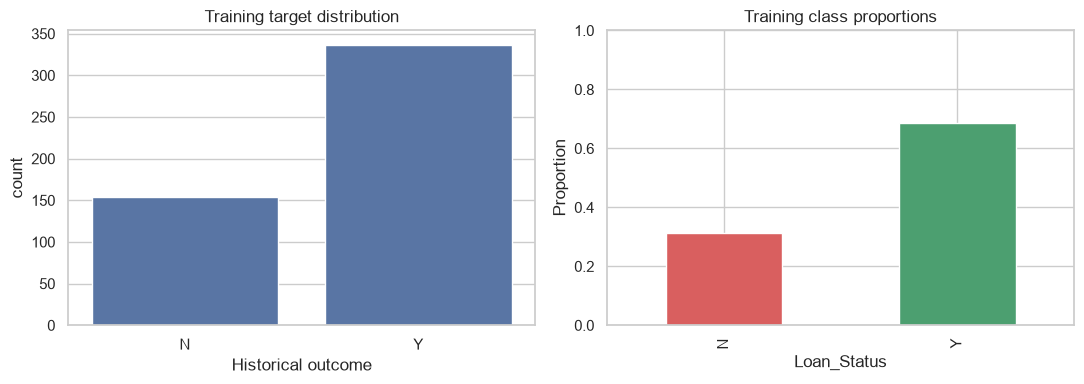

Loan_Status
N    0.313646
Y    0.686354
Name: proportion, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=eda_df, x="Loan_Status", order=["N", "Y"], ax=axes[0])
axes[0].set_title("Training target distribution")
axes[0].set_xlabel("Historical outcome")

target_rates = eda_df["Loan_Status"].value_counts(normalize=True).reindex(["N", "Y"])
target_rates.plot.bar(ax=axes[1], color=["#d95f5f", "#4c9f70"])
axes[1].set_title("Training class proportions")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
target_rates

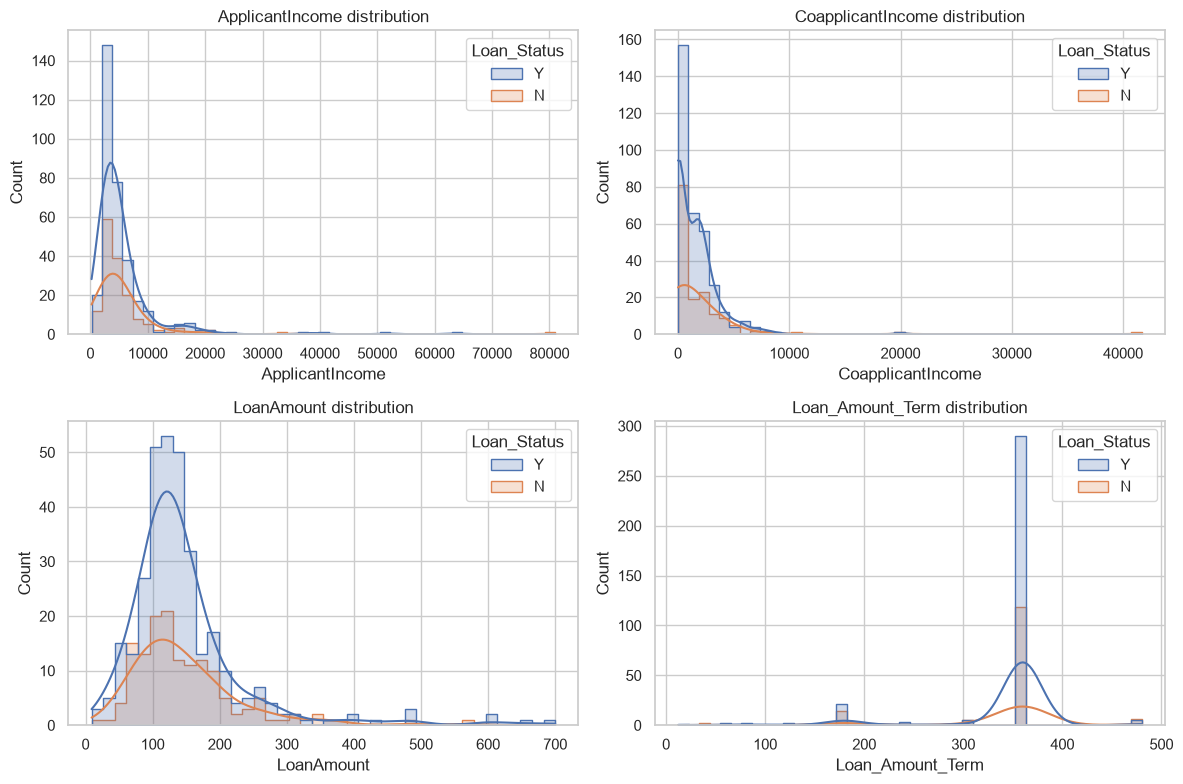

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_columns = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

for ax, column in zip(axes.flat, plot_columns):
    sns.histplot(data=eda_df, x=column, hue="Loan_Status", kde=True, element="step", ax=ax)
    ax.set_title(f"{column} distribution")

plt.tight_layout()
plt.show()

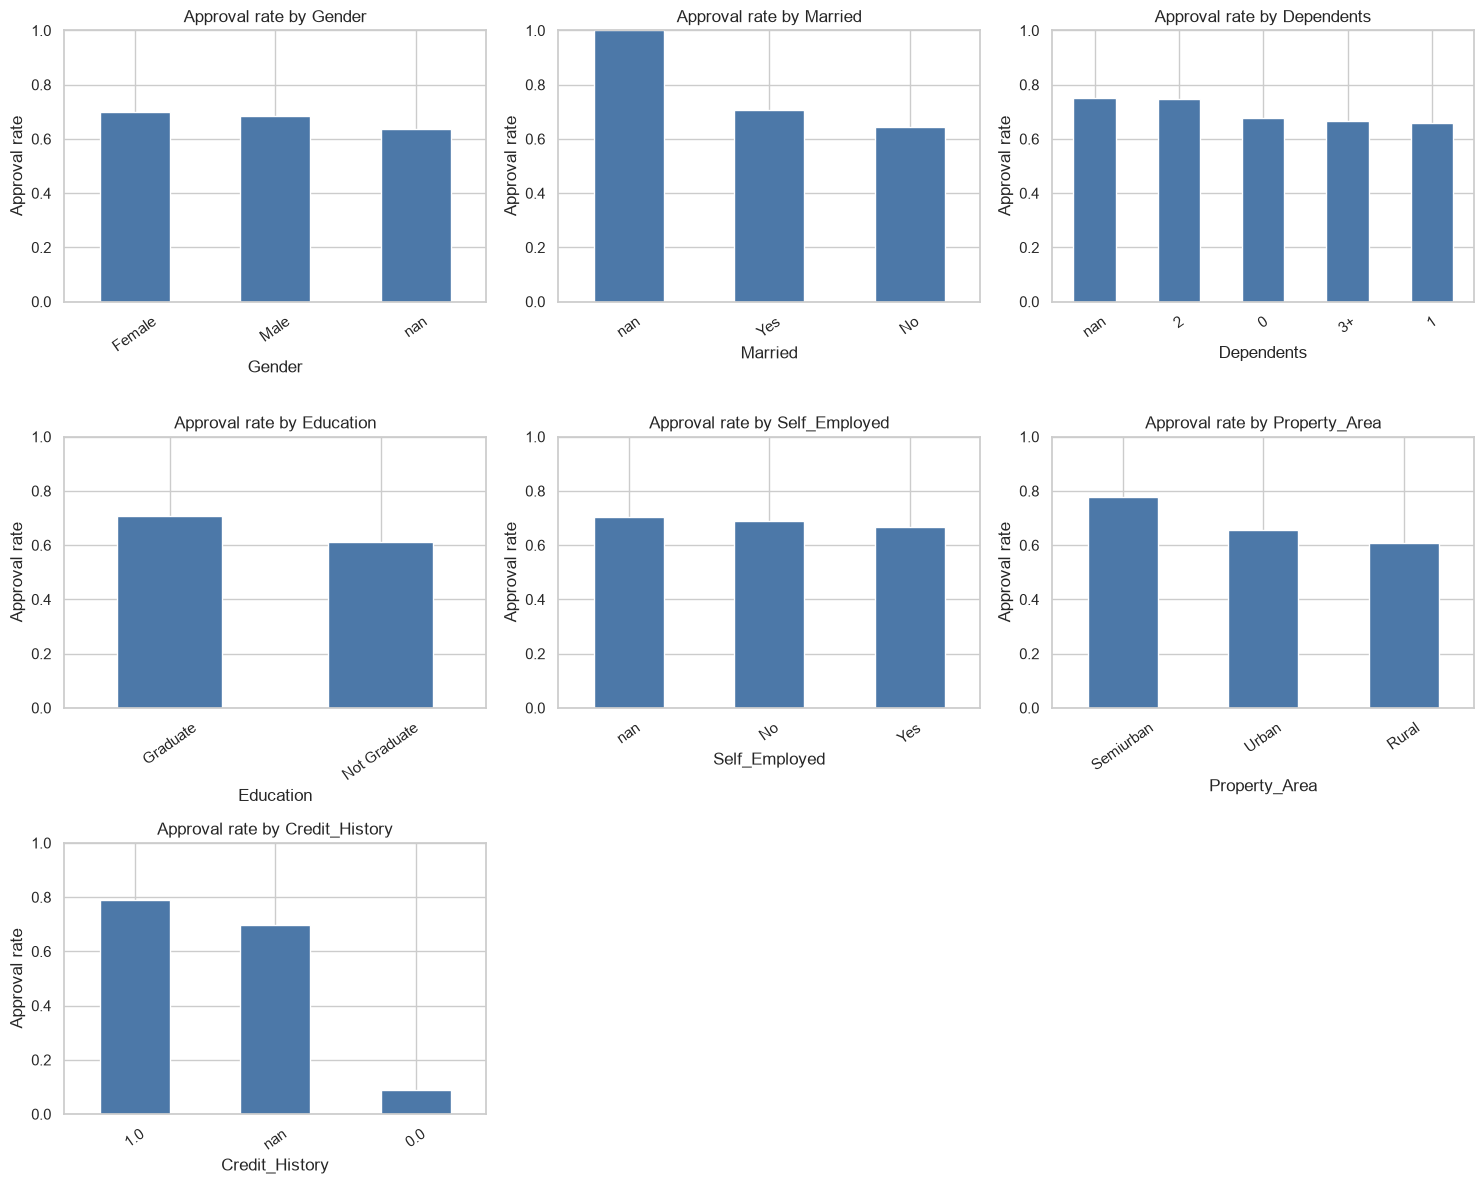

In [9]:
eda_with_target = X_train.copy()
eda_with_target["Approved"] = y_train
categorical_for_eda = CATEGORICAL_FEATURES

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, column in zip(axes.flat, categorical_for_eda):
    approval_rate = (
        eda_with_target.groupby(column, dropna=False)["Approved"]
        .mean()
        .sort_values(ascending=False)
    )
    approval_rate.plot.bar(ax=ax, color="#4c78a8")
    ax.set_title(f"Approval rate by {column}")
    ax.set_ylabel("Approval rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=35)

for ax in axes.flat[len(categorical_for_eda):]:
    ax.remove()

plt.tight_layout()
plt.show()

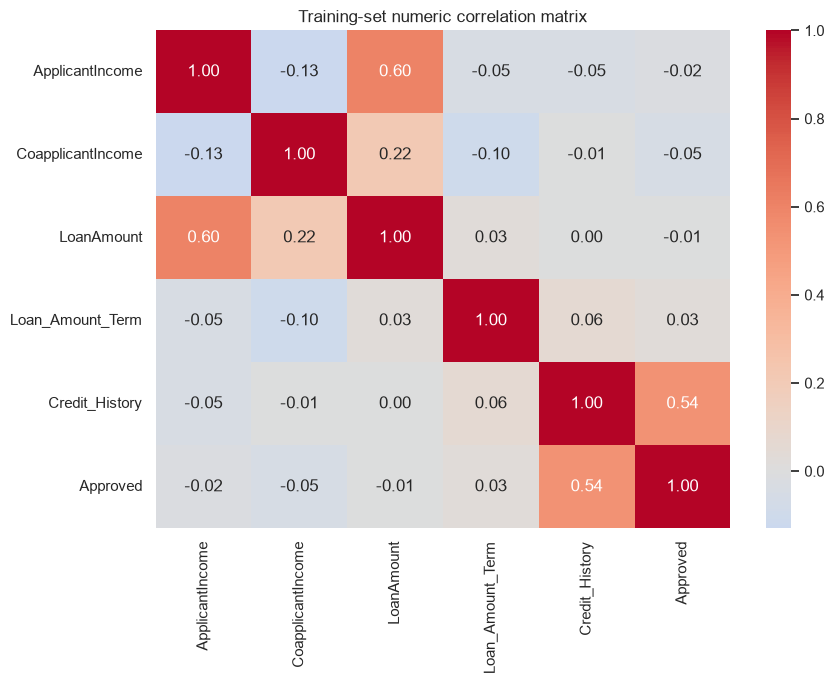

In [10]:
correlation_data = X_train[NUMERIC_FEATURES + ["Credit_History"]].copy()
correlation_data["Approved"] = y_train

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_data.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Training-set numeric correlation matrix")
plt.tight_layout()
plt.show()

### EDA observations

- The historical outcome is imbalanced, so accuracy alone is insufficient.
- Several monetary variables are strongly right-skewed and contain large values. Median imputation and scaling are therefore appropriate for the linear model.
- `Credit_History` is strongly associated with historical approval, but association is not causation.
- Missing-value treatment, encoding, scaling, and resampling are deferred to the validation pipeline.

## 5. Leakage-safe preprocessing and categorical-aware SMOTE

Numerical values are median-imputed. Categorical values are mode-imputed and ordinal-encoded temporarily so `SMOTENC` can synthesize minority examples without interpolating category labels. After resampling, numerical values are scaled and categories are one-hot encoded. Every learned step remains inside the pipeline and is refitted independently in each cross-validation fold.

In [11]:
numeric_imputer = SimpleImputer(strategy="median")
categorical_preprocessor = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "ordinal",
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    ),
])

pre_smote = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, NUMERIC_FEATURES),
        ("cat", categorical_preprocessor, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    sparse_threshold=0,
)

numeric_indices = list(range(len(NUMERIC_FEATURES)))
categorical_indices = list(
    range(len(NUMERIC_FEATURES), len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES))
)

post_smote = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_indices),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_indices,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

def build_model_pipeline(model):
    return ImbPipeline(steps=[
        ("pre_smote", clone(pre_smote)),
        (
            "smote",
            SMOTENC(
                categorical_features=categorical_indices,
                random_state=RANDOM_STATE,
            ),
        ),
        ("post_smote", clone(post_smote)),
        ("model", model),
    ])

## 6. Validation strategy and reusable metrics

The primary model-selection metric is rejected-class F1. Rejected-class recall remains visible, but optimizing recall alone could reward a model that rejects nearly everyone.

In [12]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "rejection_precision": make_scorer(
        precision_score, pos_label=REJECTION_LABEL, zero_division=0
    ),
    "rejection_recall": make_scorer(
        recall_score, pos_label=REJECTION_LABEL, zero_division=0
    ),
    "rejection_f1": make_scorer(
        f1_score, pos_label=REJECTION_LABEL, zero_division=0
    ),
    "roc_auc": "roc_auc",
}

def summarize_cross_validation(model_name, scores):
    summary = {"Model": model_name}
    for metric in SCORING:
        values = scores[f"test_{metric}"]
        summary[f"{metric}_mean"] = values.mean()
        summary[f"{metric}_std"] = values.std()
    return summary

def summarize_search(model_name, search):
    index = search.best_index_
    summary = {"Model": model_name}
    for metric in SCORING:
        summary[f"{metric}_mean"] = search.cv_results_[f"mean_test_{metric}"][index]
        summary[f"{metric}_std"] = search.cv_results_[f"std_test_{metric}"][index]
    return summary

def probability_for_label(estimator, features, label):
    class_index = int(np.flatnonzero(estimator.classes_ == label)[0])
    return estimator.predict_proba(features)[:, class_index]

## 7. Logistic regression

In [13]:
baseline_lr = build_model_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)

lr_baseline_scores = cross_validate(
    baseline_lr,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise",
)
pd.DataFrame([summarize_cross_validation("Logistic Regression (baseline)", lr_baseline_scores)])

,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,rejection_precision_mean,rejection_precision_std,rejection_recall_mean,rejection_recall_std,rejection_f1_mean,rejection_f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression (baseline),0.704618,0.062509,0.663381,0.068686,0.534758,0.095654,0.551828,0.119973,0.537187,0.095728,0.721115,0.077514


In [14]:
param_grid_lr = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
}

grid_lr = GridSearchCV(
    estimator=baseline_lr,
    param_grid=param_grid_lr,
    scoring=SCORING,
    refit="rejection_f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

print("Best logistic parameters:", grid_lr.best_params_)
pd.DataFrame([summarize_search("Logistic Regression", grid_lr)])

Best logistic parameters: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,rejection_precision_mean,rejection_precision_std,rejection_recall_mean,rejection_recall_std,rejection_f1_mean,rejection_f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.769697,0.074079,0.686413,0.064108,0.78175,0.244568,0.46172,0.079318,0.563707,0.098734,0.720863,0.083535


## 8. Random forest

In [15]:
baseline_rf = build_model_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
)

rf_baseline_scores = cross_validate(
    baseline_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise",
)
pd.DataFrame([summarize_cross_validation("Random Forest (baseline)", rf_baseline_scores)])

,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,rejection_precision_mean,rejection_precision_std,rejection_recall_mean,rejection_recall_std,rejection_f1_mean,rejection_f1_std,roc_auc_mean,roc_auc_std
0,Random Forest (baseline),0.73725,0.060756,0.672831,0.060071,0.614358,0.129941,0.49957,0.07252,0.546456,0.084796,0.716129,0.055543


In [16]:
param_grid_rf = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 8],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt"],
}

grid_rf = GridSearchCV(
    estimator=baseline_rf,
    param_grid=param_grid_rf,
    scoring=SCORING,
    refit="rejection_f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best random-forest parameters:", grid_rf.best_params_)
pd.DataFrame([summarize_search("Random Forest", grid_rf)])

Best random-forest parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}


,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,rejection_precision_mean,rejection_precision_std,rejection_recall_mean,rejection_recall_std,rejection_f1_mean,rejection_f1_std,roc_auc_mean,roc_auc_std
0,Random Forest,0.743373,0.053013,0.679128,0.05159,0.625746,0.11822,0.506237,0.067482,0.554725,0.073962,0.723437,0.057105


## 9. XGBoost

In [17]:
baseline_xgb = build_model_pipeline(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
)

xgb_baseline_scores = cross_validate(
    baseline_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    error_score="raise",
)
pd.DataFrame([summarize_cross_validation("XGBoost (baseline)", xgb_baseline_scores)])

,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,rejection_precision_mean,rejection_precision_std,rejection_recall_mean,rejection_recall_std,rejection_f1_mean,rejection_f1_std,roc_auc_mean,roc_auc_std
0,XGBoost (baseline),0.729128,0.052239,0.682871,0.065984,0.570913,0.083532,0.55828,0.123887,0.559403,0.096921,0.727108,0.056015


In [18]:
param_grid_xgb = {
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=baseline_xgb,
    param_grid=param_grid_xgb,
    scoring=SCORING,
    refit="rejection_f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print("Best XGBoost parameters:", grid_xgb.best_params_)
pd.DataFrame([summarize_search("XGBoost", grid_xgb)])

Best XGBoost parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__subsample': 0.8}


,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,rejection_precision_mean,rejection_precision_std,rejection_recall_mean,rejection_recall_std,rejection_f1_mean,rejection_f1_std,roc_auc_mean,roc_auc_std
0,XGBoost,0.735312,0.046009,0.685745,0.044349,0.596383,0.094343,0.552043,0.081934,0.566456,0.063784,0.745363,0.067192


## 10. Cross-validated model comparison

Models are selected using training-fold results only. The test set is not consulted.

In [19]:
comparison = pd.DataFrame([
    summarize_search("Logistic Regression", grid_lr),
    summarize_search("Random Forest", grid_rf),
    summarize_search("XGBoost", grid_xgb),
]).sort_values("rejection_f1_mean", ascending=False).reset_index(drop=True)

display_columns = [
    "Model",
    "rejection_f1_mean",
    "rejection_recall_mean",
    "rejection_precision_mean",
    "balanced_accuracy_mean",
    "roc_auc_mean",
]
display(comparison[display_columns].style.format(precision=3))

fitted_candidates = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
}
selected_model_name = comparison.loc[0, "Model"]
selected_estimator = fitted_candidates[selected_model_name]
print("Selected from cross-validation:", selected_model_name)

,Model,rejection_f1_mean,rejection_recall_mean,rejection_precision_mean,balanced_accuracy_mean,roc_auc_mean
0,XGBoost,0.566,0.552,0.596,0.686,0.745
1,Logistic Regression,0.564,0.462,0.782,0.686,0.721
2,Random Forest,0.555,0.506,0.626,0.679,0.723


Selected from cross-validation: XGBoost


## 11. Probability calibration

First, XGBoost's raw and sigmoid-calibrated out-of-fold probabilities are compared with the Brier score. The selected model is then calibrated using training folds only.

,Probability model,OOF Brier score
0,Raw XGBoost,0.184510
1,Sigmoid-calibrated XGBoost,0.170797


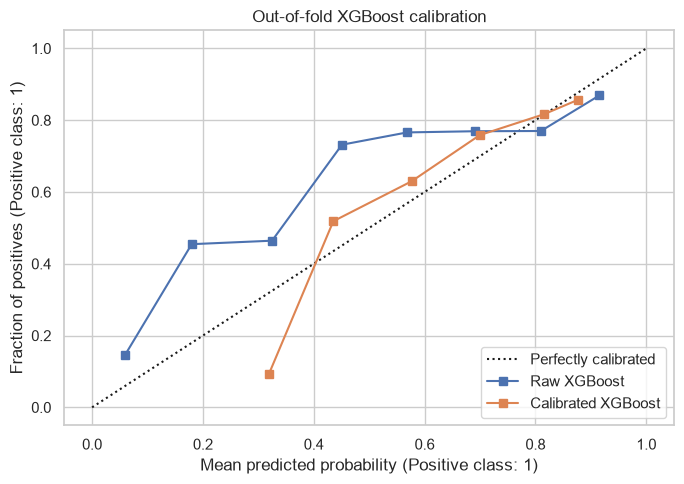

In [20]:
calibrated_xgb_template = CalibratedClassifierCV(
    estimator=best_xgb,
    method="sigmoid",
    cv=3,
)

xgb_oof_raw = cross_val_predict(
    best_xgb, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, APPROVAL_LABEL]
xgb_oof_calibrated = cross_val_predict(
    calibrated_xgb_template,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, APPROVAL_LABEL]

xgb_calibration_scores = pd.DataFrame({
    "Probability model": ["Raw XGBoost", "Sigmoid-calibrated XGBoost"],
    "OOF Brier score": [
        brier_score_loss(y_train, xgb_oof_raw),
        brier_score_loss(y_train, xgb_oof_calibrated),
    ],
})
display(xgb_calibration_scores)

fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(y_train, xgb_oof_raw, n_bins=8, name="Raw XGBoost", ax=ax)
CalibrationDisplay.from_predictions(
    y_train, xgb_oof_calibrated, n_bins=8, name="Calibrated XGBoost", ax=ax
)
ax.set_title("Out-of-fold XGBoost calibration")
plt.tight_layout()
plt.show()

In [21]:
if selected_model_name == "XGBoost":
    final_model_template = calibrated_xgb_template
else:
    final_model_template = CalibratedClassifierCV(
        estimator=selected_estimator,
        method="sigmoid",
        cv=3,
    )

oof_approval_probability = cross_val_predict(
    final_model_template,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, APPROVAL_LABEL]

final_model = clone(final_model_template).fit(X_train, y_train)
print("Calibrated final model fitted on the training partition.")

Calibrated final model fitted on the training partition.


## 12. Decision-threshold optimization

The threshold is selected from out-of-fold training probabilities, never from test predictions. Rejected-class F1 is optimized to balance rejected-class precision and recall.

Selected approval threshold: 0.680


,value
threshold,0.680000
rejection_precision,0.545977
rejection_recall,0.616883
rejection_f1,0.579268


,threshold,rejection_precision,rejection_recall,rejection_f1
decision_rule,,,,
Default threshold,0.500,0.765,0.403,0.528
Selected threshold,0.680,0.546,0.617,0.579


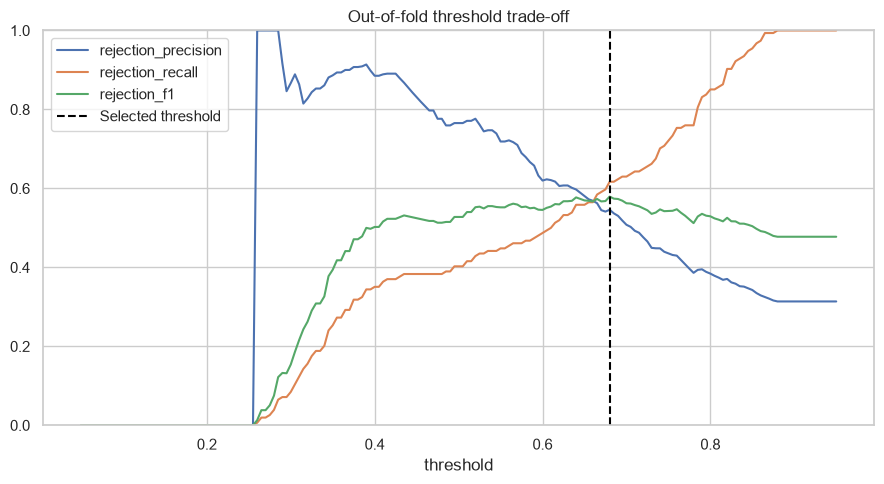

In [22]:
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 181):
    predictions = (oof_approval_probability >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "rejection_precision": precision_score(
            y_train, predictions, pos_label=REJECTION_LABEL, zero_division=0
        ),
        "rejection_recall": recall_score(
            y_train, predictions, pos_label=REJECTION_LABEL, zero_division=0
        ),
        "rejection_f1": f1_score(
            y_train, predictions, pos_label=REJECTION_LABEL, zero_division=0
        ),
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["rejection_f1", "rejection_recall", "rejection_precision"],
    ascending=False,
).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print(f"Selected approval threshold: {best_threshold:.3f}")
display(best_threshold_row.to_frame("value"))

oof_threshold_comparison = pd.DataFrame([
    {
        "decision_rule": "Default threshold",
        **threshold_results.iloc[(threshold_results["threshold"] - 0.50).abs().argmin()].to_dict(),
    },
    {
        "decision_rule": "Selected threshold",
        **best_threshold_row.to_dict(),
    },
]).set_index("decision_rule")
display(oof_threshold_comparison.style.format(precision=3))

ax = threshold_results.plot(
    x="threshold",
    y=["rejection_precision", "rejection_recall", "rejection_f1"],
    figsize=(9, 5),
)
ax.axvline(best_threshold, color="black", linestyle="--", label="Selected threshold")
ax.set_ylim(0, 1)
ax.set_title("Out-of-fold threshold trade-off")
ax.legend()
plt.tight_layout()
plt.show()

## 13. One-time evaluation on the untouched test set

In [23]:
test_approval_probability = probability_for_label(
    final_model, X_test, APPROVAL_LABEL
)
test_rejection_probability = 1.0 - test_approval_probability
test_predictions = (test_approval_probability >= best_threshold).astype(int)

test_metrics = pd.DataFrame([{
    "selected_model": selected_model_name,
    "approval_threshold": best_threshold,
    "accuracy": accuracy_score(y_test, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "rejection_precision": precision_score(
        y_test, test_predictions, pos_label=REJECTION_LABEL, zero_division=0
    ),
    "rejection_recall": recall_score(
        y_test, test_predictions, pos_label=REJECTION_LABEL, zero_division=0
    ),
    "rejection_f1": f1_score(
        y_test, test_predictions, pos_label=REJECTION_LABEL, zero_division=0
    ),
    "approval_roc_auc": roc_auc_score(y_test, test_approval_probability),
    "rejection_average_precision": average_precision_score(
        (y_test == REJECTION_LABEL).astype(int), test_rejection_probability
    ),
    "brier_score": brier_score_loss(y_test, test_approval_probability),
}])

display(test_metrics.T.rename(columns={0: "value"}))
print(classification_report(
    y_test,
    test_predictions,
    labels=[REJECTION_LABEL, APPROVAL_LABEL],
    target_names=["Rejected (0)", "Approved (1)"],
    zero_division=0,
))

,value
selected_model,XGBoost
approval_threshold,0.68
accuracy,0.764228
balanced_accuracy,0.742105
rejection_precision,0.604651
rejection_recall,0.684211
rejection_f1,0.641975
approval_roc_auc,0.798762
rejection_average_precision,0.737126
brier_score,0.148614


              precision    recall  f1-score   support

Rejected (0)       0.60      0.68      0.64        38
Approved (1)       0.85      0.80      0.82        85

    accuracy                           0.76       123
   macro avg       0.73      0.74      0.73       123
weighted avg       0.77      0.76      0.77       123



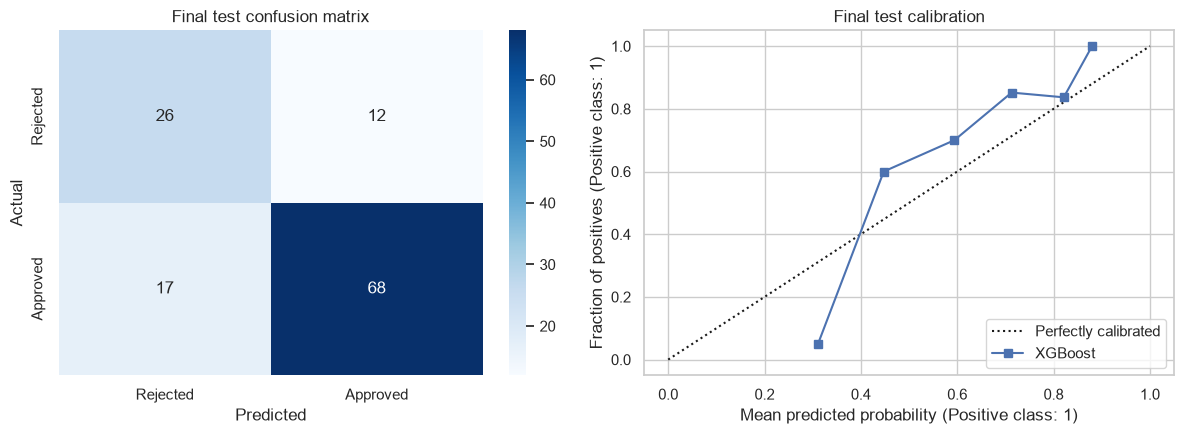

In [24]:
matrix = confusion_matrix(
    y_test, test_predictions, labels=[REJECTION_LABEL, APPROVAL_LABEL]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"],
    ax=axes[0],
)
axes[0].set_title("Final test confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

CalibrationDisplay.from_predictions(
    y_test, test_approval_probability, n_bins=8, name=selected_model_name, ax=axes[1]
)
axes[1].set_title("Final test calibration")

plt.tight_layout()
plt.show()

## 14. Model explainability

Global importance is shown for all three tuned models. Logistic local contributions use the actual transformed values, fixing the original notebook's raw-value coefficient multiplication error. Contributions are changes in the underlying logistic model's log-odds, not causal effects.

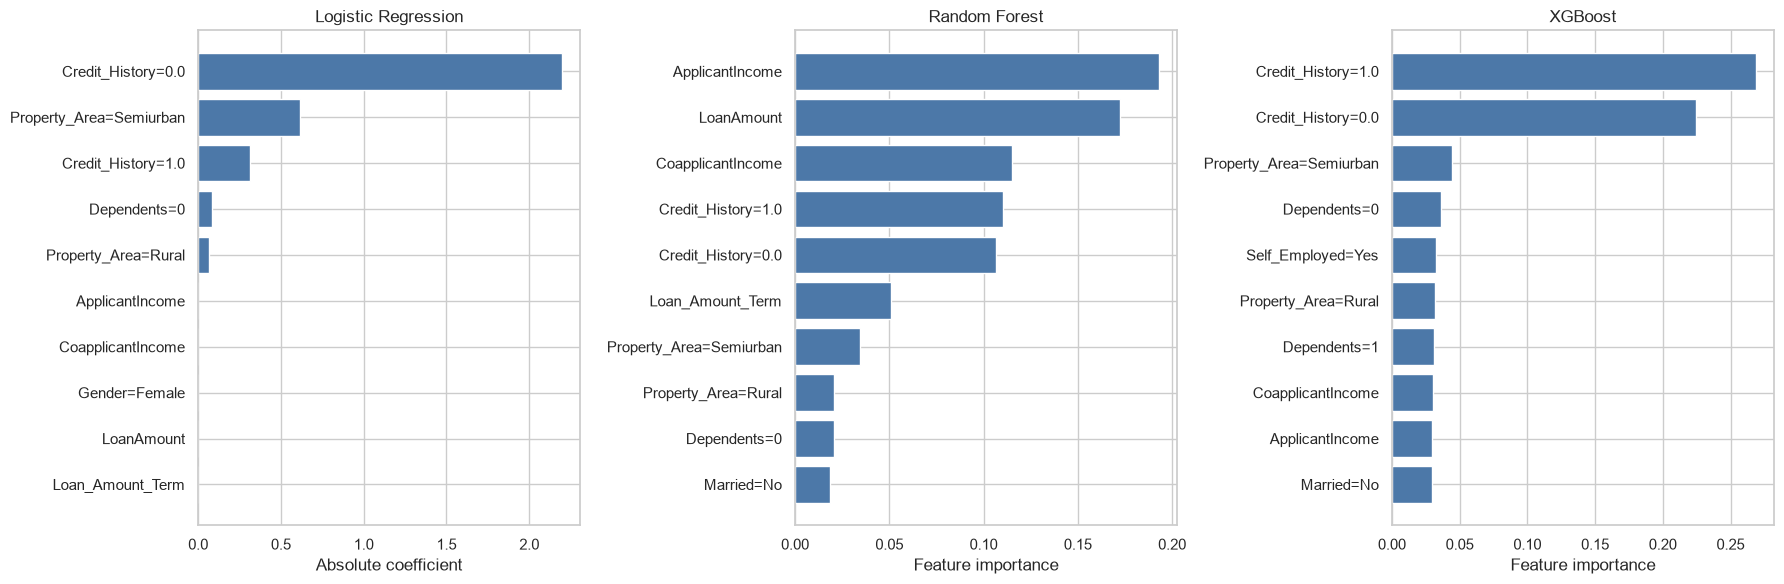

In [25]:
def transformed_feature_names(fitted_pipeline):
    ordinal = (
        fitted_pipeline.named_steps["pre_smote"]
        .named_transformers_["cat"]
        .named_steps["ordinal"]
    )
    one_hot = fitted_pipeline.named_steps["post_smote"].named_transformers_["cat"]

    names = list(NUMERIC_FEATURES)
    for feature, original_levels, encoded_levels in zip(
        CATEGORICAL_FEATURES, ordinal.categories_, one_hot.categories_
    ):
        for encoded_level in encoded_levels:
            code = int(round(float(encoded_level)))
            label = original_levels[code] if 0 <= code < len(original_levels) else "unknown"
            names.append(f"{feature}={label}")
    return np.asarray(names)

def global_importance(fitted_pipeline, model_name):
    names = transformed_feature_names(fitted_pipeline)
    model = fitted_pipeline.named_steps["model"]

    if hasattr(model, "coef_"):
        signed = model.coef_[0]
        importance = np.abs(signed)
    else:
        signed = np.full(len(names), np.nan)
        importance = model.feature_importances_

    return pd.DataFrame({
        "feature": names,
        "importance": importance,
        "signed_coefficient": signed,
        "model": model_name,
    }).sort_values("importance", ascending=False)

importance_tables = {
    "Logistic Regression": global_importance(best_lr, "Logistic Regression"),
    "Random Forest": global_importance(best_rf, "Random Forest"),
    "XGBoost": global_importance(best_xgb, "XGBoost"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (model_name, table) in zip(axes, importance_tables.items()):
    top = table.head(10).sort_values("importance")
    ax.barh(top["feature"], top["importance"], color="#4c78a8")
    ax.set_title(model_name)
    ax.set_xlabel("Absolute coefficient" if model_name == "Logistic Regression" else "Feature importance")

plt.tight_layout()
plt.show()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
150,Male,No,0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural


,feature,transformed_value,coefficient,log_odds_contribution,absolute_contribution
19,Credit_History=0.0,1.000000,-2.198074,-2.198074,2.198074
8,Dependents=0,1.000000,-0.084638,-0.084638,0.084638
16,Property_Area=Rural,1.000000,-0.066597,-0.066597,0.066597
1,CoapplicantIncome,-0.598288,0.000000,-0.000000,0.000000
0,ApplicantIncome,0.143107,0.000000,0.000000,0.000000
4,Gender=Female,0.000000,0.000000,0.000000,0.000000
3,Loan_Amount_Term,0.275589,0.000000,0.000000,0.000000
2,LoanAmount,-0.356017,0.000000,-0.000000,0.000000
5,Gender=Male,1.000000,0.000000,0.000000,0.000000
9,Dependents=1,0.000000,0.000000,0.000000,0.000000


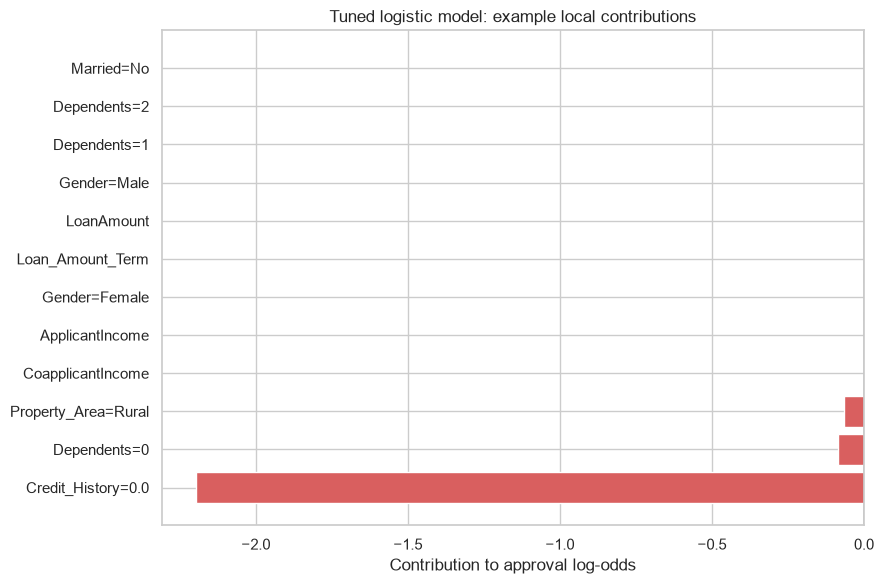

In [26]:
def logistic_contributions(fitted_pipeline, raw_row):
    pre_smote_values = fitted_pipeline.named_steps["pre_smote"].transform(raw_row)
    transformed_values = fitted_pipeline.named_steps["post_smote"].transform(pre_smote_values)
    coefficients = fitted_pipeline.named_steps["model"].coef_[0]
    names = transformed_feature_names(fitted_pipeline)

    return pd.DataFrame({
        "feature": names,
        "transformed_value": transformed_values[0],
        "coefficient": coefficients,
        "log_odds_contribution": transformed_values[0] * coefficients,
    }).assign(
        absolute_contribution=lambda frame: frame["log_odds_contribution"].abs()
    ).sort_values("absolute_contribution", ascending=False)

example_application = X_test.iloc[[0]]
example_contributions = logistic_contributions(best_lr, example_application)
display(example_application)
display(example_contributions.head(12))

top = example_contributions.head(12).sort_values("log_odds_contribution")
colors = np.where(top["log_odds_contribution"] >= 0, "#4c9f70", "#d95f5f")
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["log_odds_contribution"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Contribution to approval log-odds")
plt.title("Tuned logistic model: example local contributions")
plt.tight_layout()
plt.show()

## 15. Limitations and responsible use

- The source does not document when, where, or under which lending policy the observations were collected. Results may not generalize to current applicants or other regions.
- `Loan_Status` records a historical approval decision; it is not repayment performance, financial loss, or default risk.
- Historical decisions can encode human and policy bias, particularly through demographic attributes. Fairness must be audited before any real-world use.
- The dataset is small, and SMOTE creates training examples rather than new ground-truth observations.
- This notebook's feature set, model choice, and test metrics differ from the packaged inference pipeline.


## 16. Reproduce the packaged workflow

From the repository root, run uv run --link-mode copy loan-approval train. It validates the CSV and writes the API-compatible bundle to models/loan_approval.joblib plus a detailed local report. The tracked result is reports/evaluation.json. This notebook does not export deployment artifacts; its XGBoost result remains a separate exploration.

## Final checklist

- Raw data is split before learned preprocessing.
- EDA uses the training partition only.
- Imputation, encoding, scaling, and `SMOTENC` run inside every validation fold.
- Logistic regression, random forest, and XGBoost are tuned with the same folds and metrics.
- Model selection, probability calibration, and threshold selection use training data only.
- The untouched test set is evaluated once.
- Logistic contributions use transformed values and are described as associations, not causes.
- The packaged training command, not this notebook, creates the model served by FastAPI.